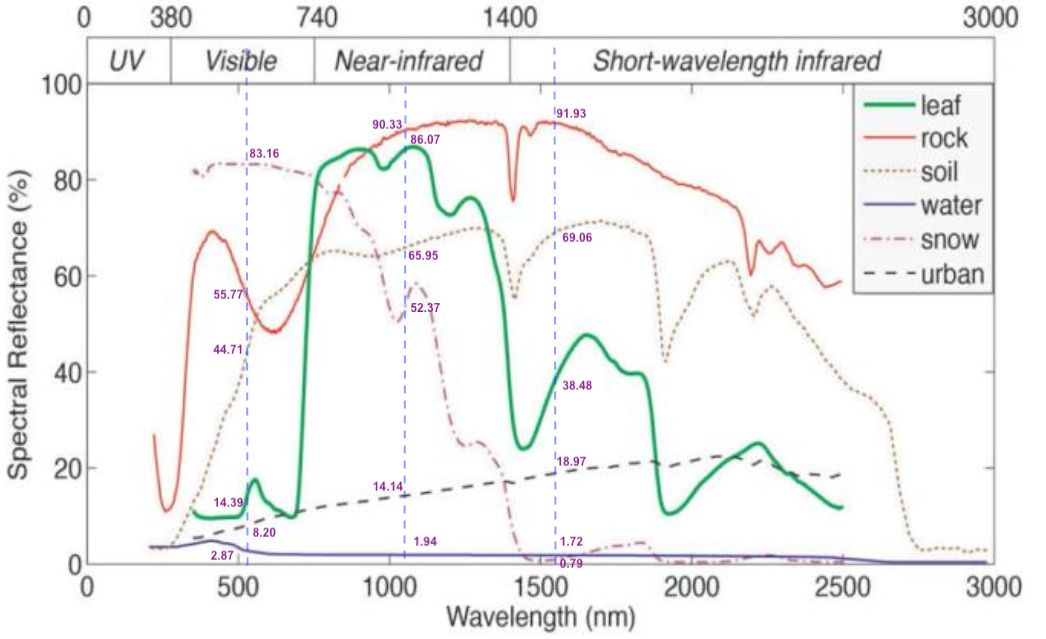

Material	Reflectance at 532 nm (%)	Reflectance at 1040 nm (%)	Reflectance at 1550 nm (%)
Water	2.87	1.94	1.72
Urban	8.2	14.14	18.97
Leaf	14.39	86.07	38.48
Soil	44.71	65.95	69.06
Rock	55.77	90.33	91.93
Snow	83.16	52.37	0.79

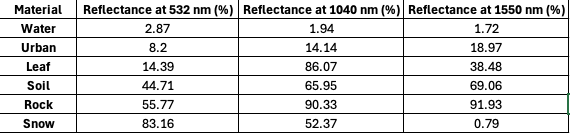

  Material     N_sent_532nm  N_recv_532nm    N_sent_1040nm  N_recv_1040nm  \
0    Water  401448837911258             0  784787201931783              0   
1    Urban  401448837911258             0  784787201931783              0   
2     Leaf  401448837911258             0  784787201931783              0   
3     Soil  401448837911258             0  784787201931783              0   
4     Rock  401448837911258             0  784787201931783              0   
5     Snow  401448837911258             0  784787201931783              0   

      N_sent_1550nm  N_recv_1550nm  
0  1169634772109870              0  
1  1169634772109870              0  
2  1169634772109870              0  
3  1169634772109870              0  
4  1169634772109870              1  
5  1169634772109870              0  


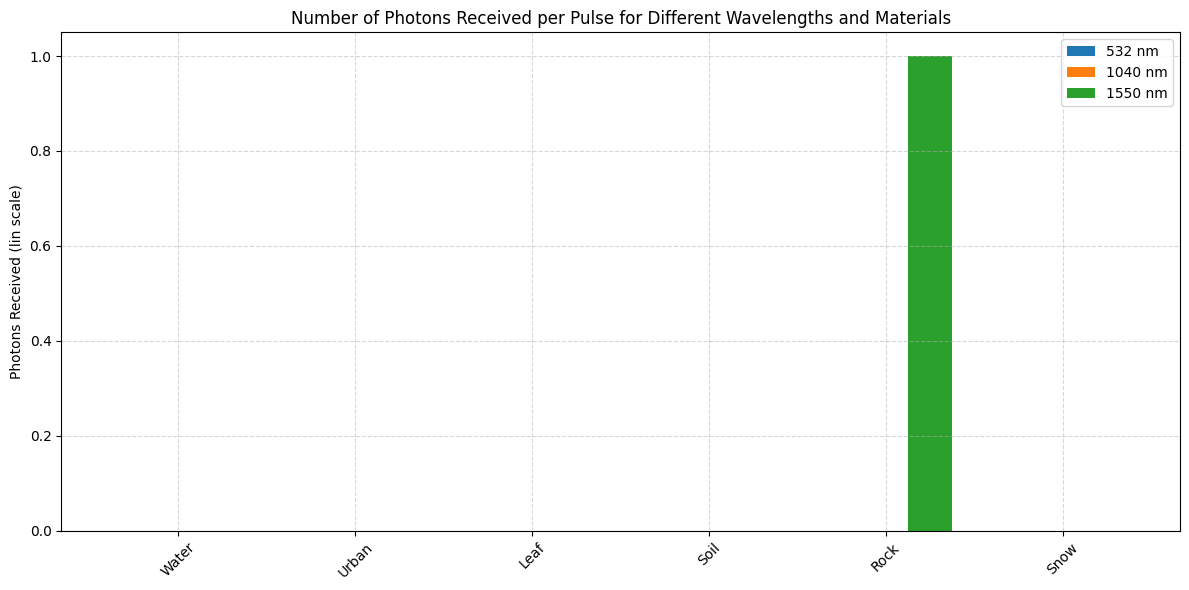

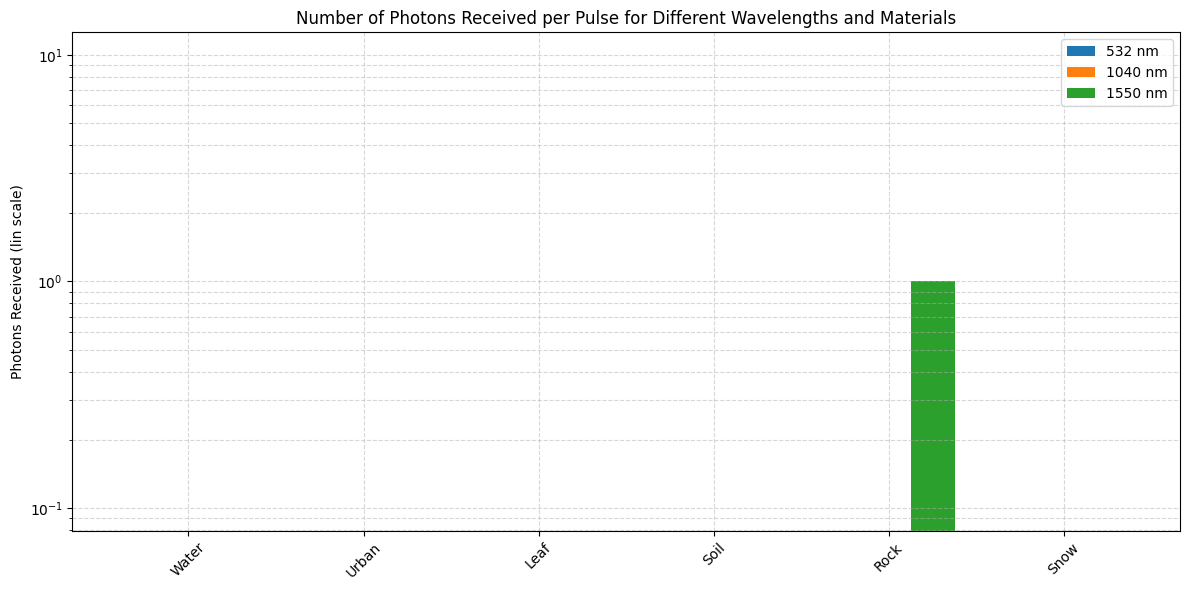

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constants
h = 6.626e-34  # Planck, J.s
c = 3e8        # Speed of light, m/s

# Parameters
E_pulse = 150e-6       # Pulse energy in Joules
wavelengths = np.array([532e-9, 1040e-9, 1550e-9])  # meters
R = 500e3               # Orbit altitude, m
D_telescope = 0.6       # Telescope diameter, m
QE = 0.9                # Detector quantum efficiency
Spot= 10               # swath in meter

# Reflectivity table
reflectivity = {
    "Water": [2.87, 1.94, 1.72],
    "Urban": [8.2, 14.14, 18.97],
    "Leaf": [14.39, 86.07, 38.48],
    "Soil": [44.71, 65.95, 69.06],
    "Rock": [55.77, 90.33, 91.93],
    "Snow": [83.16, 52.37, 0.79]
}

# Telescope area
A_r = np.pi * (D_telescope/2)**2

# Spot size on ground (fixed at 10m footprint for 20 µrad divergence)
A_spot = np.pi * (Spot/2)**2

# Coupling factor (telescope vs footprint)
coupling = A_r / A_spot

def photons_sent(E, wavelength):
    return E / (h * c / wavelength)

def photons_received(E, wavelength, reflectivity, A_r, R, QE):
    E_r = E * reflectivity * coupling * A_r / (np.pi * R**2)
    N_r = E_r / (h * c / wavelength) * QE
    return N_r

# DataFrame to store results
results = []

for mat, rho_list in reflectivity.items():
    row = {"Material": mat}
    for i, lam in enumerate(wavelengths):
        rho = rho_list[i] / 100  # convert % to fraction
        N_sent = photons_sent(E_pulse, lam)
        N_recv = photons_received(E_pulse, lam, rho, A_r, R, QE)
        row[f"N_sent_{int(lam*1e9)}nm"] = int(N_sent)
        row[f"N_recv_{int(lam*1e9)}nm"] = int(N_recv)
    results.append(row)

df = pd.DataFrame(results)
print(df)

# Plot Linear
materials = df['Material']
x = np.arange(len(materials))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))

for i, lam in enumerate(wavelengths):
    ax.bar(x + i*width, df[f"N_recv_{int(lam*1e9)}nm"], width, label=f"{int(lam*1e9)} nm")

ax.set_xticks(x + width)
ax.set_xticklabels(materials, rotation=45)
#ax.set_yscale('log')  # Log scale for photon count
ax.set_ylabel("Photons Received (lin scale)")
ax.set_title("Number of Photons Received per Pulse for Different Wavelengths and Materials")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Plot Log
fig, ax = plt.subplots(figsize=(12,6))

for i, lam in enumerate(wavelengths):
    ax.bar(x + i*width, df[f"N_recv_{int(lam*1e9)}nm"], width, label=f"{int(lam*1e9)} nm")

ax.set_xticks(x + width)
ax.set_xticklabels(materials, rotation=45)
ax.set_yscale('log')  # Log scale for photon count
ax.set_ylabel("Photons Received (lin scale)")
ax.set_title("Number of Photons Received per Pulse for Different Wavelengths and Materials")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [3]:
print (rho)

0.0079
